In [1]:
from functions import *
import matplotlib.pyplot as plt
def get_QLF(z, bin_num, dM, obscured, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf = QLF(z, bin_num)
    qlf.get_dNdMstar(smhm_scat)
    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL


In [5]:
%prun get_QLF(2,100,.6,.7, Mmid=10.7,standev = [.85,.85,.3])


         4593 function calls (4588 primitive calls) in 0.046 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      101    0.007    0.000    0.007    0.000 functions.py:95(get_Mstar)
        3    0.004    0.001    0.004    0.001 fromnumeric.py:2847(ndim)
        5    0.003    0.001    0.023    0.005 shape_base.py:270(apply_along_axis)
      100    0.002    0.000    0.002    0.000 functions.py:131(gauss_array)
      100    0.002    0.000    0.004    0.000 functions.py:189(get_mean_etas)
       10    0.002    0.000    0.002    0.000 fromnumeric.py:592(transpose)
        1    0.002    0.002    0.002    0.002 necompiler.py:765(evaluate)
       10    0.002    0.000    0.002    0.000 {method 'reshape' of 'numpy.ndarray' objects}
        2    0.002    0.001    0.006    0.003 cosmology.py:2140(sigma)
        3    0.001    0.000    0.001    0.000 {built-in method scipy.interpolate._fitpack._spl_}
        2    0.001    0.001    0.001 

Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

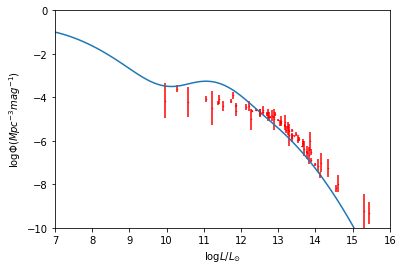

In [2]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
z = 2.
xi, yi = get_QLF(z,100,.3,.75, Mmid=10.,standev = [.85,.85,.3])
plt.plot(xi, yi)
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')


MCMC stuff.

In [3]:
import emcee
import corner
import scipy.optimize as op
from functions import *
import matplotlib.pyplot as plt

In [3]:
def model_func(x, p):
    p1, p2 = p
    xm, ym = get_QLF_mcmc(p1, p2)
    y = np.interp(x, xm, ym)
    return y

def lnchi2(p, x, y, err): #lnlike
    
    chi2 = -0.5*np.sum((y-model_func(x,p))**2/(err**2))
    return chi2

def lnprior(p):
    p1, p2 = p
    if 0. < p1 < 3. and 0. < p2 < 1.:
        return 0.0
    return -np.inf

def lnprob(p, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, x, y, err)
    return -np.inf

z = 3.
bin_num = 200
smhm_scat = .3

qlf = QLF(z, bin_num)
qlf.get_zparams()
qlf.get_dNdMstar(smhm_scat)

### if we go through mcmc for one z value without changing the bin_num of smhm scatter we can do this
def get_QLF_mcmc(dM, obscured, Mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL



In [10]:
xt, yt , yerr = np.array(grab_obs(z))
p = [.5,.5]
ndim, nwalkers = 2, 20

nll = lambda *args: -lnchi2(*args)
result = op.minimize(nll, p, args=(xt, yt, yerr),method = 'Nelder-Mead')

pos = [result["x"] + .1*np.random.randn(ndim) for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(xt,yt,yerr))
sampler.run_mcmc(pos,500)
##more jumps and bigger jumps
##understand results and do a joint fit with all redshifts
##corner plots

print(result)


 final_simplex: (array([[0.47396103, 0.7666021 ],
       [0.47396159, 0.76668088],
       [0.47396269, 0.7665707 ]]), array([55.53897186, 55.53903504, 55.53904082]))
           fun: 55.53897186114615
       message: 'Optimization terminated successfully.'
          nfev: 113
           nit: 59
        status: 0
       success: True
             x: array([0.47396103, 0.7666021 ])


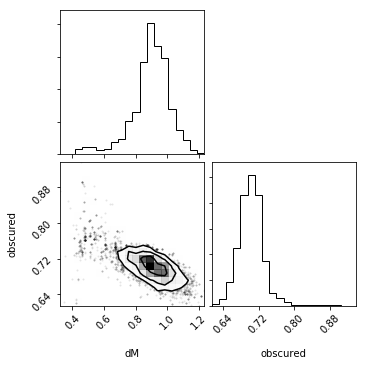

In [11]:
samples = sampler.chain[:,:,:].reshape((-1, ndim))
fig = corner.corner(samples, labels = ['dM','obscured'])
mcmcdM, mcmcObs = np.mean(samples[:,0]), np.mean(samples[:,1])


Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

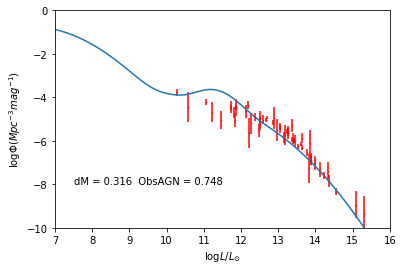

In [23]:
xi, yi = get_QLF_mcmc(mcmcdM, mcmcObs)
plt.plot(xi, yi)
plt.text(7.5,-8,r'dM = '+str(mcmcdM)[:5]+'  ObsAGN = '+str(mcmcObs)[:5])
plt.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')

Stuff I did to fix the interp issue.

13.000000000000007
11.243362186272641 13.000000000000007
12.900000000000007


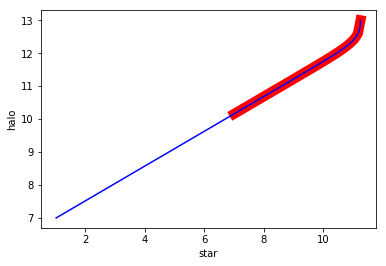

In [13]:
z = 5.
bin_num = 20
Lum = [5,16]
Stell = [7,12]

qlf = QLF(z, bin_num)


max_halo = 15
mhalo = np.linspace(7,max_halo,50)
mstar_h = qlf.get_Mstar(mhalo)

plt.xlabel('star')
plt.ylabel('halo')
stop = np.argmin(sorted(mstar_h) == mstar_h)
while stop != 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    mstar_h = qlf.get_Mstar(mhalo)
    stop = np.argmin(sorted(mstar_h) == mstar_h)
    
    
max_stell = qlf.get_Mstar(max_halo)
mstar = np.linspace(7,max_stell,50)
mhalo_s = np.interp(mstar, mstar_h, mhalo)
    
plt.plot(mstar, mhalo_s, c='r',linewidth=10)
plt.plot(mstar_h, mhalo, c = 'b')
print(max_stell, max_halo)

slopes = qlf.get_slope(mhalo)
while slopes[-1] < 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    slopes = qlf.get_slope(mhalo)
print(max_halo)

doing MCMC for lots of redshift.

Fitting for three parameters: dM, obscured fraction of AGN, and the middle stellar mass value.

In [44]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
bin_num = 200
smhm_scat = .3

def get_QLF_mcmc(p, i, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    ob = .5
    dm, obs, mmid = p
    i.get_SMBM(dm, mmid)
    i.get_dNdMbh()
    i.get_dNdL(prob_zero, standev, ob)
    
    return i.LumBins, i.dNdL

def model_func_op(x, p, i):
    xm, ym = get_QLF_mcmc(p, i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2_op(p, i, x, y, err): #lnlike
    
    chi2 = np.sum((y - model_func_op(x, p, i)) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

qlf_00 = QLF(0.0, bin_num)
qlf_01 = QLF(0.1, bin_num)
qlf_02 = QLF(0.2, bin_num)
qlf_05 = QLF(0.5, bin_num)    
qlf_10 = QLF(1.0, bin_num)
qlf_15 = QLF(1.5, bin_num)
qlf_20 = QLF(2.0, bin_num)
qlf_25 = QLF(2.5, bin_num)
qlf_30 = QLF(3.0, bin_num)
qlf_35 = QLF(3.5, bin_num)
qlf_40 = QLF(4.0, bin_num)
qlf_45 = QLF(4.5, bin_num)
qlf_50 = QLF(5.0, bin_num)
qlf_55 = QLF(5.5, bin_num)
qlf_60 = QLF(6.0, bin_num)

qlf_list = [qlf_00, qlf_01, qlf_02, qlf_05, qlf_10, qlf_15, qlf_20, qlf_25, qlf_30, qlf_35, qlf_40, qlf_45, qlf_50, qlf_55, qlf_60]

for i in qlf_list:
    i.get_dNdMstar(smhm_scat)

xt_tot = []
yt_tot = []
yerr_tot = []
z_tot = []
for z in zlist:
    x, y, yerr = grab_obs(z)
    xt_tot.extend(x)
    yt_tot.extend(y)
    yerr_tot.extend(yerr)
    for j in range(len(x)):
        z_tot.append(z)

p = [.2, 0.65, 10.3]
nll = lambda *args: -lnchi2_op(*args)
results = []
results_unbound = []
bonds = ((0.01,3.0),(.4,.8),(10.,10.8))
for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'L-BFGS-B', bounds = bonds)["x"])
    results_unbound.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'Nelder-Mead', bounds = None)["x"])
    #TNC  SLSQP   L-BFGS-B for bounds
    #Nelder-Mead is what I used first
pinit = np.sum(np.array(results),axis=0)/len(results)
pinit_unbound = np.sum(np.array(results_unbound),axis=0)/len(results)
print(pinit, pinit_unbound)

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in double_scalars
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:663: RuntimeWarning: invalid value encountered in double_scalars
  grad[k] = (f(*((xk + d,) + args)) - f0) / d[k]
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:171: RuntimeWarning: invalid value encountered in less_equal
  self.early = (self.StellBins <= self.mass_cuts[0])
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:172: RuntimeWarning: invalid value encountered in greater
  self.growth = ((self.StellBins > self.mass_cuts[0]) & (self.StellBins < self.mass_cuts[1]))
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:172: RuntimeWarning: invalid value encountered in less
  self.growth = ((self.StellBins > self.mass_cuts[0]) & (self.StellBi

[ 0.25012854  0.65       10.33574753] [ 0.21205596  0.65128843 10.57285848]


In [45]:
def lnprior(p):
    dm, ob, mmid = p
    if 0.0 < dm <= 3.0 and 0.0 < ob < 1.0 and 10. < mmid < 10.8:
        return 0.0
    return -np.inf

def lnprob(p, i, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, i, x, y, err)
    return -np.inf

def lnchi2(p, z, x, y, err): #lnlike
    
    chi2 = np.sum((model_func(x, p, z) - y) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

def model_func(x, p, z, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    y = []
    dm, ob, mmid = p
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(dm, mmid)
        i.get_dNdMbh()
        i.get_dNdL(prob_zero, standev, ob)
        xm, ym = i.LumBins, i.dNdL
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y

m_true = -0.9594
b_true = 4.294
f_true = 0.534

N = 50
x = np.sort(10*np.random.rand(N))
yerr = 0.1+0.5*np.random.rand(N)
y = m_true*x+b_true
y += np.abs(f_true*y) * np.random.randn(N)
y += yerr * np.random.randn(N)

def lnlike(theta, x, y, yerr):
    m, b, lnf = theta
    model = m * x + b
    inv_sigma2 = 1.0/(yerr**2 + model**2*np.exp(2*lnf))
    return -0.5*(np.sum((y-model)**2*inv_sigma2 - np.log(inv_sigma2)))

print(lnchi2(pinit_unbound, np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
print(lnlike([-0.95,4.29,.53],x,y,yerr))

-8.676409278968105
-58.05154107098012


In [50]:
ndim, nwalkers, steps = 3, 10, 500
# myp = [.2, .7, 10.3]
# pos = [np.array([(myp[0] + np.random.randint(-1,2)*np.random.random_sample(1)*.2)[0], myp[1] + (np.random.randint(-1,2)*np.random.random_sample(1)*.2)[0], (myp[2] + np.random.randint(-1,2)*np.random.random_sample(1)*.4)[0]]) for n in range(nwalkers)]
pos = [pinit + .1*np.random.randn(3) for i in range(nwalkers)]
for i in range(len(pos)):
    for j in range(len(pos[i])):
        if pos[i][j] < 0.0:
            pos[i][j] = 0.1
print('start sampler')
sampler_3fit = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
%time sampler_3fit.run_mcmc(pos, steps)
print('end sampler')


start sampler
CPU times: user 4min 29s, sys: 2.77 s, total: 4min 31s
Wall time: 4min 43s
end sampler


[0.192 0.262 0.284 0.254 0.186 0.288 0.256 0.246 0.248 0.222]


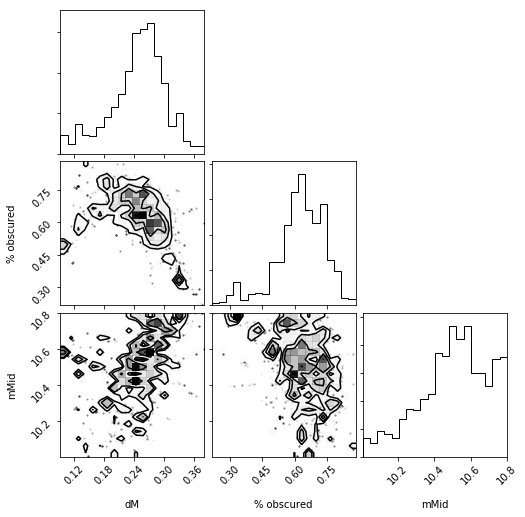

In [51]:
samples_3fit = sampler_3fit.chain[:,10:,:].reshape((-1,ndim))
print(sampler_3fit.acceptance_fraction)
fig = corner.corner(samples_3fit, labels = ['dM','% obscured', 'mMid'])

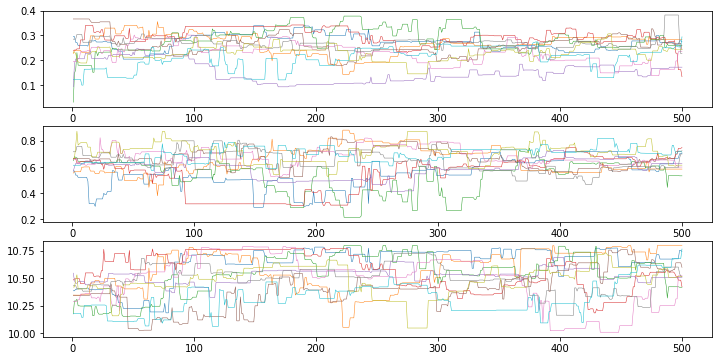

In [52]:
import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(3, 1)
fig = plt.figure(figsize=(12,6))

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

for w in sampler1.chain[:,:,:]:
    dmy = []
    oby = []
    mmidy = []
    for y in w:
        dmy.append(y[0])
        oby.append(y[1])
        mmidy.append(y[2])
    x = np.linspace(1,steps,steps)
    ax0.plot(x,dmy,linewidth=0.5)
    ax1.plot(x,oby,linewidth=0.5)
    ax2.plot(x,mmidy,linewidth=0.5)

Fitting for two parameters: dM and obscured fraction of AGN.

In [4]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
bin_num = 200
smhm_scat = .3

def get_QLF_mcmc(p, i, mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    ob = .5
    dm, obs = p
    i.get_SMBM(dm, mmid)
    i.get_dNdMbh()
    i.get_dNdL(prob_zero, standev, ob)
    
    return i.LumBins, i.dNdL

def model_func_op(x, p, i):
    xm, ym = get_QLF_mcmc(p, i)
    y = np.interp(x, xm, ym)
    return y

def lnchi2_op(p, i, x, y, err): #lnlike
    
    chi2 = np.sum((y - model_func_op(x, p, i)) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

qlf_00 = QLF(0.0, bin_num)
qlf_01 = QLF(0.1, bin_num)
qlf_02 = QLF(0.2, bin_num)
qlf_05 = QLF(0.5, bin_num)    
qlf_10 = QLF(1.0, bin_num)
qlf_15 = QLF(1.5, bin_num)
qlf_20 = QLF(2.0, bin_num)
qlf_25 = QLF(2.5, bin_num)
qlf_30 = QLF(3.0, bin_num)
qlf_35 = QLF(3.5, bin_num)
qlf_40 = QLF(4.0, bin_num)
qlf_45 = QLF(4.5, bin_num)
qlf_50 = QLF(5.0, bin_num)
qlf_55 = QLF(5.5, bin_num)
qlf_60 = QLF(6.0, bin_num)

qlf_list = [qlf_00, qlf_01, qlf_02, qlf_05, qlf_10, qlf_15, qlf_20, qlf_25, qlf_30, qlf_35, qlf_40, qlf_45, qlf_50, qlf_55, qlf_60]

for i in qlf_list:
    i.get_dNdMstar(smhm_scat)

xt_tot = []
yt_tot = []
yerr_tot = []
z_tot = []
for z in zlist:
    x, y, yerr = grab_obs(z)
    xt_tot.extend(x)
    yt_tot.extend(y)
    yerr_tot.extend(yerr)
    for j in range(len(x)):
        z_tot.append(z)

p = [.2, 0.65]
nll = lambda *args: -lnchi2_op(*args)
results = []
results_unbound = []
bonds = ((0.01,3.0),(.4,.8))
for i, z in zip(qlf_list, zlist):
    xt, yt, yerr = np.array(grab_obs(z))
    results.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'L-BFGS-B', bounds = bonds)["x"])
    results_unbound.append(op.minimize(nll, p, args=(i, xt, yt, yerr), method = 'Nelder-Mead', bounds = None)["x"])
    #TNC  SLSQP   L-BFGS-B for bounds
    #Nelder-Mead is what I used first
pinit = np.sum(np.array(results),axis=0)/len(results)
pinit_unbound = np.sum(np.array(results_unbound),axis=0)/len(results)
print(pinit, pinit_unbound)


/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:178: RuntimeWarning: divide by zero encountered in true_divide
  self.dNdMbh = self.dNdMstar / self.m
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:205: RuntimeWarning: divide by zero encountered in log10
  return np.log10(eta)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:269: RuntimeWarning: invalid value encountered in multiply
  self.dNdL = np.log10(np.sum(np.apply_along_axis(self.prob_eddratios, 1, vals, obscured) * np.reshape(self.dNdMbh,(self.bin_num,1)) * (self.StellBins[1] - self.StellBins[0]) * np.reshape(self.m,(self.bin_num,1)), axis = 0))
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in double_scalars
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:663: RuntimeWarning: invalid value enc

[0.26658143 0.65      ] [0.21315735 0.63864014]


In [5]:
def lnprior(p):
    dm, ob = p
    if 0.0 < dm <= 3.0 and 0.0 < ob < 1.0:
        return 0.0
    return -np.inf

def lnprob(p, i, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, i, x, y, err)
    return -np.inf

def lnchi2(p, z, x, y, err): #lnlike
    
    chi2 = np.sum((model_func(x, p, z) - y) ** 2 / (err ** 2)) / (len(x)-1)
    return -chi2

def model_func(x, p, z, mmid = 10.3, prob_zero = [0,0,0], standev = [.85, .75, .35]):
    y = []
    dm, ob = p
    z = np.array(z)
    for zs, i in zip(zlist, qlf_list):
        i.get_SMBM(dm, mmid)
        i.get_dNdMbh()
        i.get_dNdL(prob_zero, standev, ob)
        xm, ym = i.LumBins, i.dNdL
        where = (z == zs)  
        y.extend(np.interp(np.array(x)[where], xm, ym))
    return y


In [31]:
ndim, nwalkers, steps = 2, 10, 200
pos = [pinit + .1*np.random.randn(2) for i in range(nwalkers)]
for i in range(len(pos)):
    for j in range(len(pos[i])):
        if pos[i][j] < 0.0:
            pos[i][j] = 0.1
print('start sampler')
sampler_2fit = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
%time sampler_2fit.run_mcmc(pos, steps)
print('end sampler')


start sampler
CPU times: user 4min 58s, sys: 1.65 s, total: 4min 59s
Wall time: 5min 4s
end sampler


In [41]:
ndim, nwalkers, steps = 2, 30, 500
pos = [pinit + .1*np.random.randn(2) for i in range(nwalkers)]
for i in range(len(pos)):
    for j in range(len(pos[i])):
        if pos[i][j] < 0.0:
            pos[i][j] = 0.1
print('start sampler')
sampler_2fit_multicore = emcee.EnsembleSampler(nwalkers, ndim, lnprob, threads = 5, args=(np.array(z_tot), np.array(xt_tot), np.array(yt_tot), np.array(yerr_tot)))
%time sampler_2fit_multicore.run_mcmc(pos, steps)
print('end sampler')


start sampler
CPU times: user 5.72 s, sys: 1.34 s, total: 7.06 s
Wall time: 20min 39s
end sampler


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:41: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  acf = np.fft.ifft(f * np.conjugate(f), axis=axis)[m].real
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:43: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return acf / acf[m]
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:105: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated

[23.60994354 23.14192587]
[0.625 0.61  0.62  0.555 0.58  0.595 0.54  0.555 0.65  0.615]


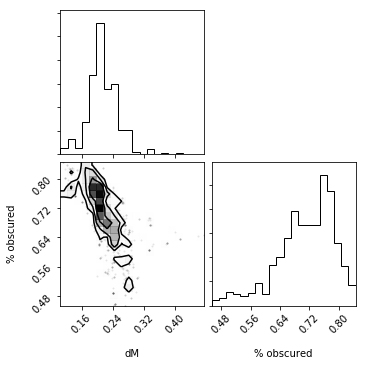

In [38]:
samples_2fit = sampler_2fit.chain[:,2:,:].reshape((-1,ndim))
print(sampler_2fit.get_autocorr_time(c=1, low = 10))
print(sampler_2fit.acceptance_fraction)
fig = corner.corner(samples_2fit, labels = ['dM','% obscured'])

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:41: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  acf = np.fft.ifft(f * np.conjugate(f), axis=axis)[m].real
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:43: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return acf / acf[m]
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/emcee/autocorr.py:105: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated

[64.65670509 69.90148814]
[0.608 0.566 0.57  0.648 0.612 0.574 0.572 0.594 0.552 0.582 0.548 0.588
 0.586 0.604 0.596 0.618 0.686 0.612 0.6   0.606 0.602 0.634 0.566 0.56
 0.606 0.612 0.616 0.606 0.558 0.606]


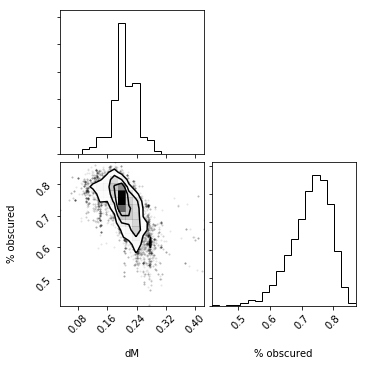

In [42]:
samples_2fit_multicore = sampler_2fit_multicore.chain[:,2:,:].reshape((-1,ndim))
print(sampler_2fit_multicore.get_autocorr_time(c=1, low = 10))
print(sampler_2fit_multicore.acceptance_fraction)
fig = corner.corner(samples_2fit_multicore, labels = ['dM','% obscured'])


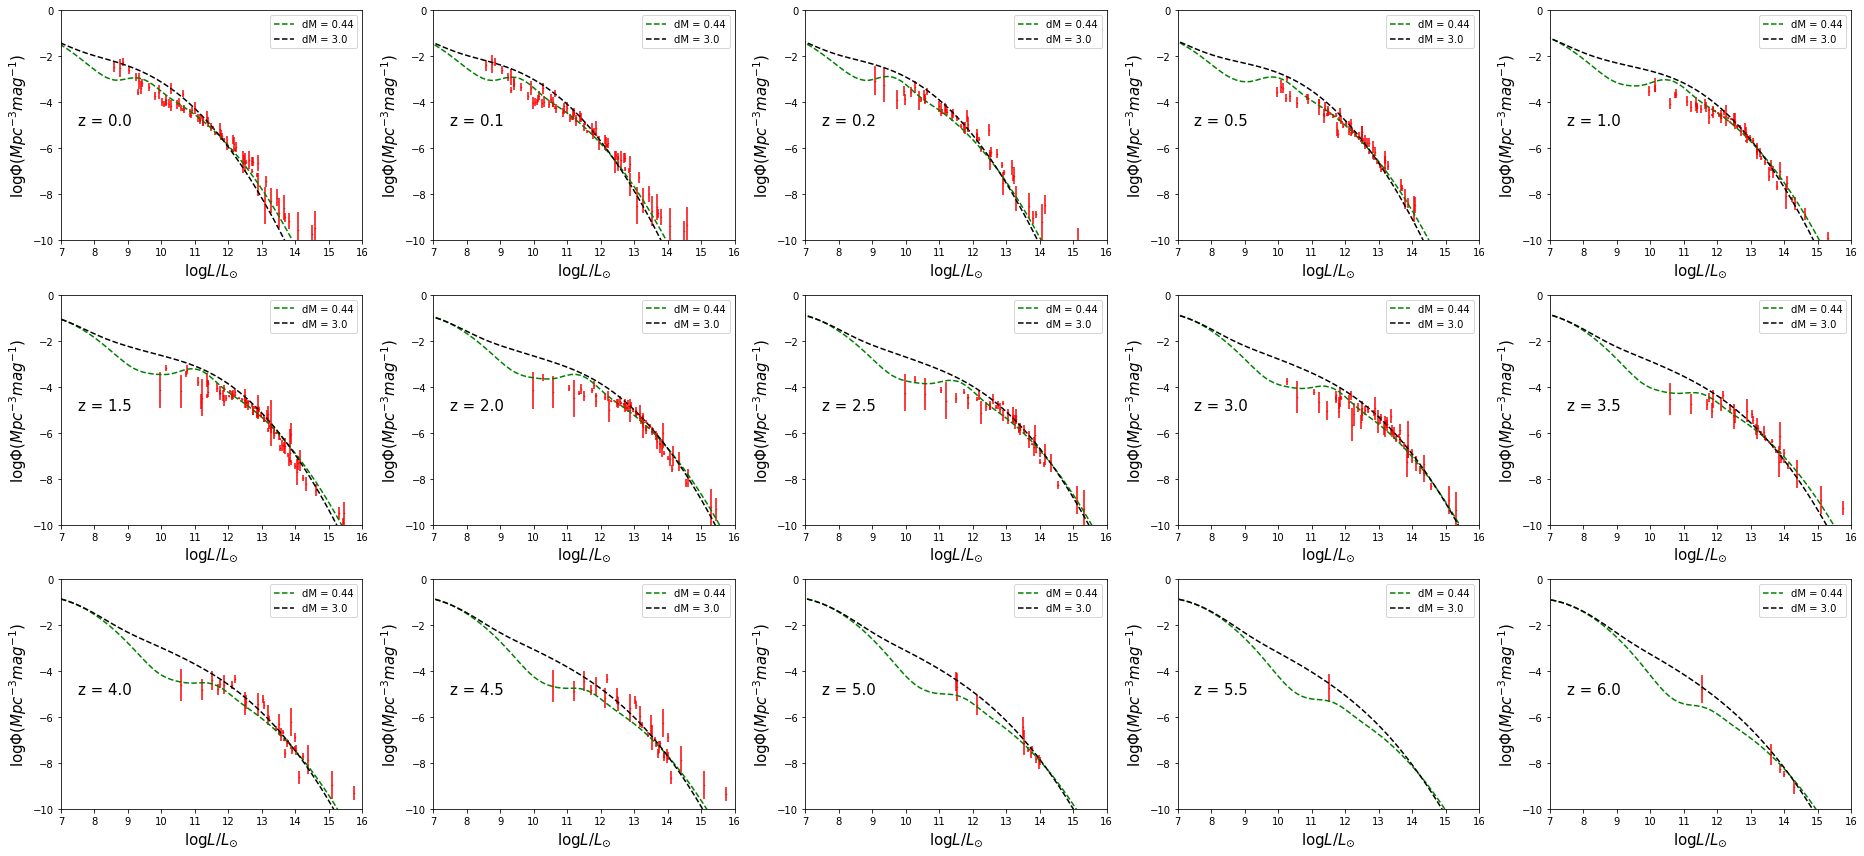

In [14]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
fs = 15
mcmc_dM_l = [0.44, 3.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    for dM,c in zip(mcmc_dM_l,['g','k']):
        xm, ym = get_QLF(z, bin_num, dM = dM, obscured = .75, Mmid = 10.3, smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35])
        ax.plot(xm,ym,label='dM = '+str(dM),linestyle='dashed',color=c)
    ax.set_xlabel(r'$\log L/L_{\odot}$',fontsize=fs)
    ax.set_ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$',fontsize=fs)
    ax.text(7.5,-5,'z = '+str(z),fontsize=fs)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
    ax.axis([7,16,-10,0])
    ax.legend()
        
plt.tight_layout()
plt.savefig('plots/MCMC_dM_QLF_v1.0.pdf')
